In [2]:
from pyarrow import feather
import pandas as pd
import matplotlib.pyplot as plt


In [3]:
table = feather.read_table('../dataset/data_andre.feather', memory_map=True)
df= table.to_pandas()
df.head()

,date,item_id,value,cat_label,sdep_label,dep_label,dmn_label,promo_type_FRPG,promo_value_FRPG,promo_type_GAS,...,promo_value_DISC,promo_type_CIRC,promo_value_CIRC,promo_type_CIRE,promo_value_CIRE,promo_type_CLCP,promo_value_CLCP,promo_type_LFPE,promo_value_LFPE,store_id
0,2021-01-23,27,8,refrigerated drnks,pos subd dairy other,pos dept dairy,cheese/yogurt/orange juice,0,0.0,0,...,0.0000,0,0.0,0,0.0,0,0.0,0,0.0,6269
1,2021-01-23,952568,6,carbonated sft drnks,pos subd grocery other,pos dept grocery,soda,0,0.0,0,...,0.0000,0,0.0,0,0.0,0,0.0,1,0.0,6269
2,2021-01-23,809,13,juices drnks shelf stbl,pos subd grocery other,pos dept grocery,juice/aseptic/new age,0,0.0,1,...,0.0000,0,0.0,0,0.0,0,0.0,0,0.0,6269
3,2021-01-23,20405,3,dairy chs,pos subd dairy other,pos dept dairy,cheese/yogurt/orange juice,0,0.0,0,...,0.1228,0,0.0,0,0.0,0,0.0,0,0.0,6269
4,2021-01-23,605573,5,refrigerated drnks,pos subd dairy other,pos dept dairy,cheese/yogurt/orange juice,0,0.0,0,...,0.0000,0,0.0,0,0.0,0,0.0,0,0.0,6269


In [4]:
df.duplicated().sum()

0

In [5]:
import pandas as pd

# 0) Clean dates
df["date"] = pd.to_datetime(df["date"]).dt.normalize()

# 1) Collapse to daily store totals (handles multiple items per day)
daily = (
    df.groupby(["store_id", "date"], as_index=False)["value"]
      .sum()
)

# --- Option A: working day = any activity row (nonzero sales) ---
open_days = daily[daily["value"] > 0]

# Per-store list of working dates
working_days_by_store = (
    open_days.groupby("store_id")["date"]
             .apply(lambda s: sorted(s.unique()))
             .to_dict()
)

# Example: working days for a specific store_id
store_id = 6269
working_days_store = working_days_by_store.get(store_id, [])

print(f"{store_id} has {len(working_days_store)} working days from {open_days['date'].min().date()} to {open_days['date'].max().date()}")
print()

# --- Determine CLOSED DAYS for the store ---
min_date_global = df["date"].min()
max_date_global = df["date"].max()

# Generate all dates in the global range
all_dates = pd.date_range(start=min_date_global, end=max_date_global, freq='D')

# Convert working_days_store to set for efficient lookup
working_days_set = set(working_days_store)

# Closed days = dates NOT in working days
closed_days_store = [d for d in all_dates if d not in working_days_set]

print(f"Store {store_id} Closure Analysis:")
print(f"  Total possible days: {len(all_dates)}")
print(f"  Working days (nonzero sales): {len(working_days_store)}")
print(f"  Closed/inactive days: {len(closed_days_store)}")
print(f"  Closure rate: {len(closed_days_store) / len(all_dates) * 100:.1f}%")
print()

# Analyze closure patterns (consecutive closure periods)
if closed_days_store:
    closed_days_sorted = sorted(closed_days_store)
    closure_periods = []
    period_start = closed_days_sorted[0]
    period_end = closed_days_sorted[0]
    
    for i in range(1, len(closed_days_sorted)):
        if (closed_days_sorted[i] - closed_days_sorted[i-1]).days == 1:
            # Continue current period
            period_end = closed_days_sorted[i]
        else:
            # End current period, start new one
            closure_periods.append((period_start, period_end, (period_end - period_start).days + 1))
            period_start = closed_days_sorted[i]
            period_end = closed_days_sorted[i]
    
    # Add final period
    closure_periods.append((period_start, period_end, (period_end - period_start).days + 1))
    
    print(f"Closure periods (consecutive closures): {len(closure_periods)}")
    print(f"Average closure period length: {sum(p[2] for p in closure_periods) / len(closure_periods):.1f} days")
    print()
    
    # Show top closure periods
    print("Top 5 longest closure periods:")
    for start, end, duration in sorted(closure_periods, key=lambda x: x[2], reverse=True)[:5]:
        print(f"  {start.date()} to {end.date()}: {duration} days")


6269 has 760 working days from 2021-01-23 to 2023-02-22

Store 6269 Closure Analysis:
  Total possible days: 761
  Working days (nonzero sales): 760
  Closed/inactive days: 1
  Closure rate: 0.1%

Closure periods (consecutive closures): 1
Average closure period length: 1.0 days

Top 5 longest closure periods:
  2022-12-25 to 2022-12-25: 1 days


In [6]:
is_christmas = (daily["date"].dt.month == 12) & (daily["date"].dt.day == 25)
daily.loc[is_christmas & (daily["store_id"] == store_id)]

,store_id,date,value
336,6269,2021-12-25,2
701,6269,2022-12-25,0


In [7]:
import holidays
import pandas as pd

# make sure date column is datetime
df["date"] = pd.to_datetime(df["date"]).dt.normalize()

# define the full date range of your dataset
min_date, max_date = df["date"].min(), df["date"].max()

# generate US federal holidays within that range
us_holidays = holidays.UnitedStates(years=range(min_date.year, max_date.year + 1), observed=True)
holiday_dates = [pd.Timestamp(d) for d in us_holidays.keys() if min_date <= pd.Timestamp(d) <= max_date]

daily = (
    df.groupby(["store_id", "date"], as_index=False)["value"]
      .sum()
      .rename(columns={"value": "sales"})
)

# .loc only on holidays
daily_holidays = daily.loc[daily["date"].isin(holiday_dates)]
daily_holidays

,store_id,date,sales
23,6269,2021-02-15,8877
128,6269,2021-05-31,8573
146,6269,2021-06-18,9654
147,6269,2021-06-19,10513
162,6269,2021-07-04,8984
163,6269,2021-07-05,9581
226,6269,2021-09-06,9898
261,6269,2021-10-11,9386
292,6269,2021-11-11,8776
306,6269,2021-11-25,3393


In [8]:
len(df["item_id"].unique())

1427

In [9]:
df["item_id"].value_counts()

item_id
27        761
901498    761
6032      761
901555    761
6035      761
         ... 
79879     595
151824    591
210048    581
151827    578
151825    569
Name: count, Length: 1427, dtype: int64

In [10]:
df["cat_label"].unique()

array(['refrigerated drnks', 'carbonated sft drnks',
       'juices drnks shelf stbl', 'dairy chs', 'sprd btr mrgrn', 'yogurt',
       'rte cereal', 'sour cream', 'milknplant based bevs',
       'bottled water', 'dy non dy crm', 'eggs egg substitutes',
       'sparkling seltzer mixer', 'dairy cream', 'refrig dsrts',
       'refrigerated baked gds', 'new age bevs', 'hot cereal', 'itln chs',
       'sprt drnk', 'cottage chs', 'cream chs', 'dips refrigerated',
       'aseptic'], dtype=object)

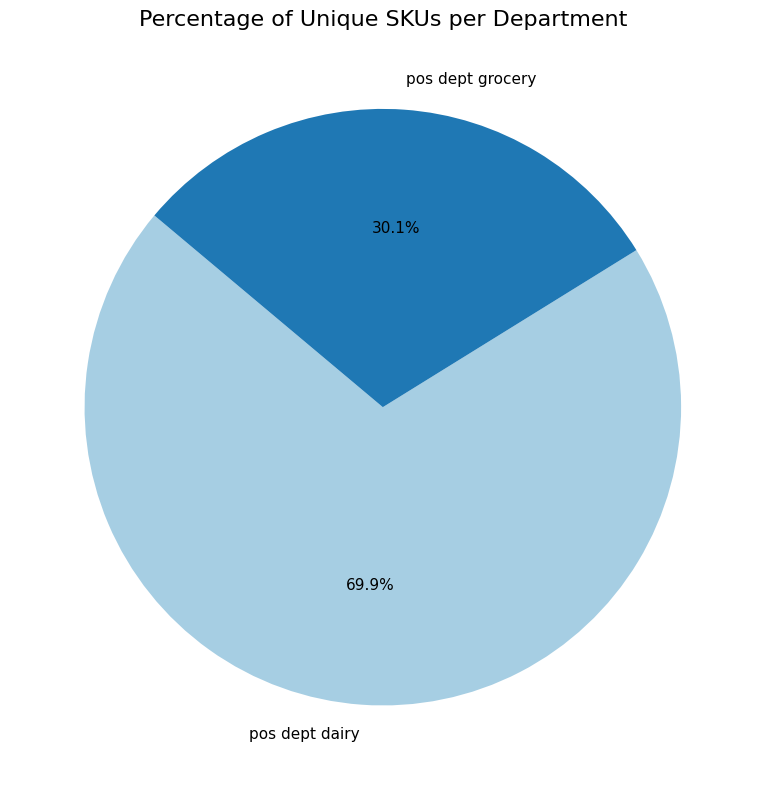

In [13]:
import matplotlib.pyplot as plt

# unique item_id per dep_label
sku_per_dep = (
    df.groupby("dep_label")["item_id"]
      .nunique()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10, 8))
# Create a pie chart with percentages
sku_per_dep.plot(
    kind='pie', 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=plt.cm.Paired.colors,
    textprops={'fontsize': 11}
)

plt.title('Percentage of Unique SKUs per Department', fontsize=16)
plt.ylabel('')  # Hide the y-label for pie charts
plt.tight_layout()
plt.show()

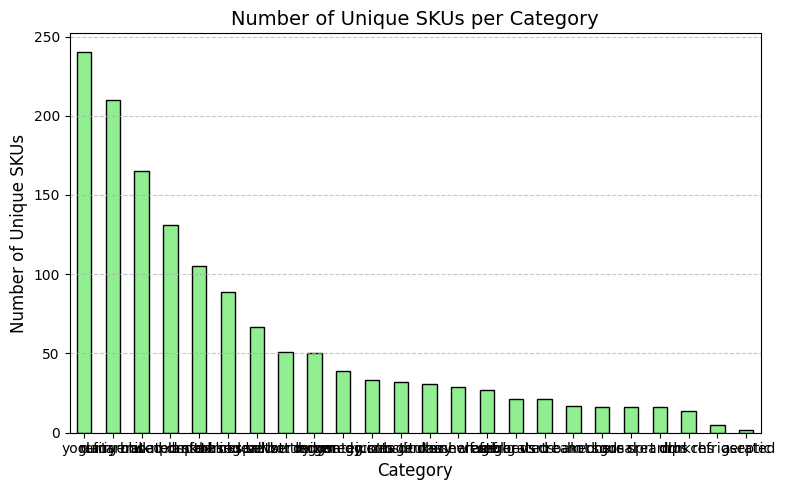

In [12]:
sku_per_category = (
    df.groupby("cat_label")["item_id"]
        .nunique()
        .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))
sku_per_category.plot(kind='bar', color='lightgreen', edgecolor='black')
plt.title('Number of Unique SKUs per Category', fontsize=14)
plt.ylabel('Number of Unique SKUs', fontsize=12)
plt.xlabel('Category', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

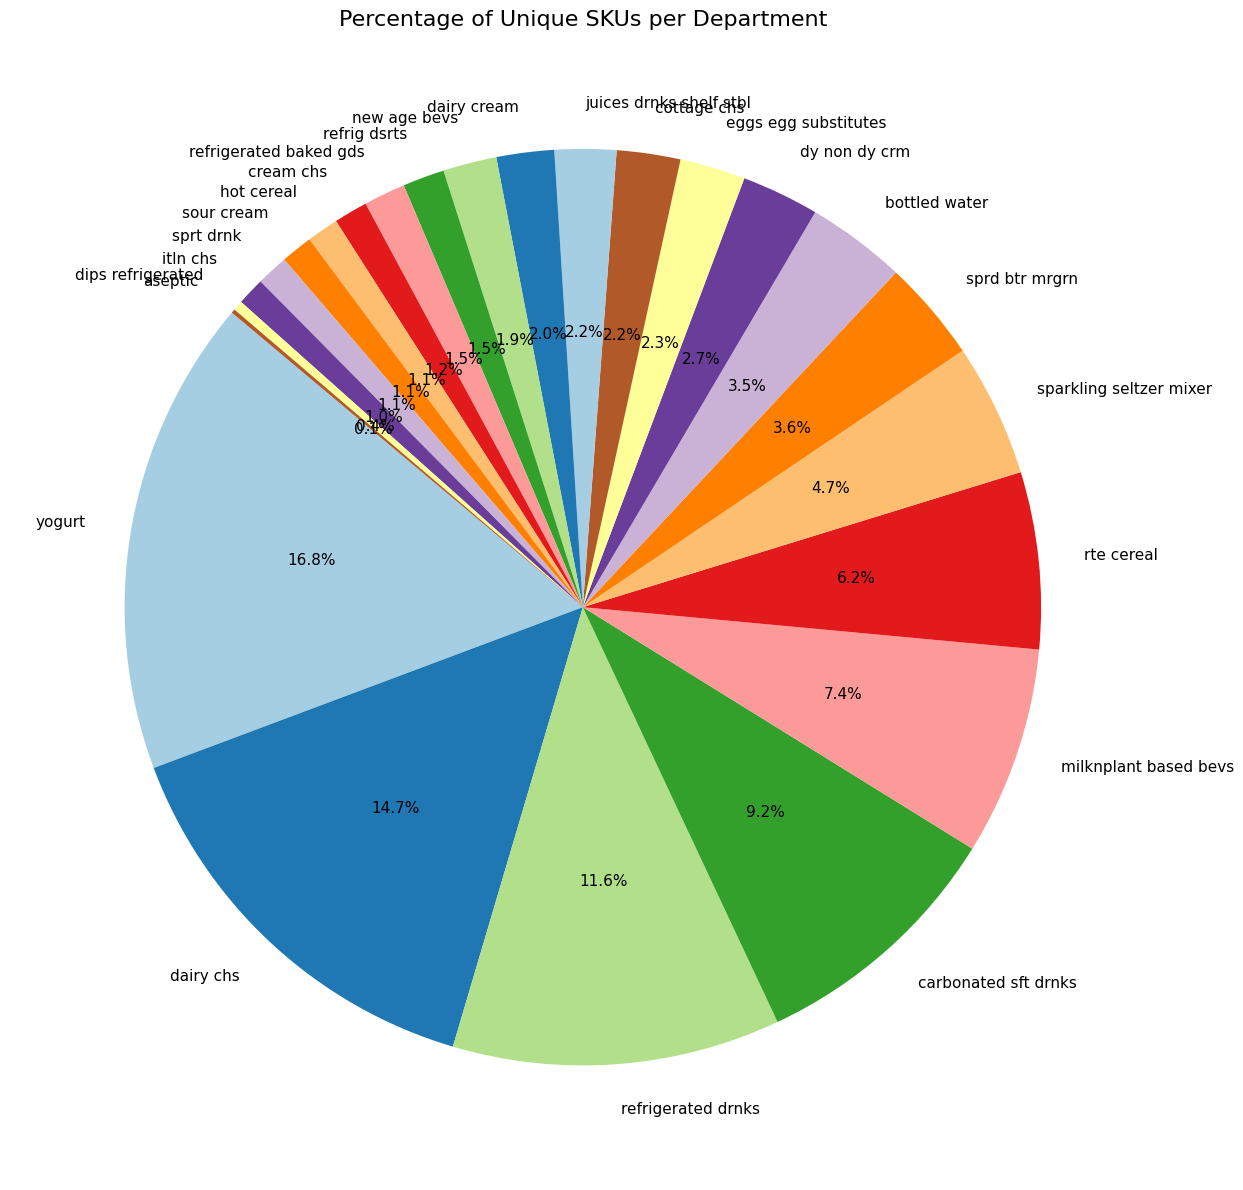

In [16]:
sku_cat_dep = (
    df.groupby("cat_label")["item_id"]
      .nunique()
      .sort_values(ascending=False)
)

plt.figure(figsize=(16, 12))
# Create a pie chart with percentages
sku_cat_dep.plot(
    kind='pie', 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=plt.cm.Paired.colors,
    textprops={'fontsize': 11}
)

plt.title('Percentage of Unique SKUs per Department', fontsize=16)
plt.ylabel('')  # Hide the y-label for pie charts
plt.tight_layout()
plt.show()

In [ ]:
# Find and display all columns related to promotions
promo_columns = [col for col in df.columns if 'promo' in col.lower()]

print(f"Found {len(promo_columns)} promo columns:")
for col in promo_columns:
    print(f"- {col}")

# Display a quick preview of just the promo columns (if any exist)
if promo_columns:
    display(df[promo_columns].head())
